# Customer Personality Analysis — Segmentation

**Goal:** Identify actionable customer segments from a CRM-style dataset of ~2,200 retail customers using and comparing three clustering algorithms — **K-Means, Agglomerative (Hierarchical), and DBSCAN** — selected via three internal validation metrics (Silhouette, Davies–Bouldin, Dunn).

**Dataset:** `customer_segmentation.csv` — 29 columns covering demographics (age, education, marital status, income, household), behavioural spend across 6 product categories (wines, fruits, meat, fish, sweets, gold), and engagement signals (web visits, store/web/catalog purchases, campaign acceptance, recency).

**Approach (one paragraph):**
1. Engineer interpretable features (Age, Total_spends, Total_children, Customer_Since, HasPartner, AcceptedAny).
2. Handle the dataset's known dirty values — `Year_Birth < 1940` (impossible ages) and the extreme `Income` outlier near 666 K — using domain rules + IQR.
3. Encode categoricals (Education ordinal, Marital_Status → binary partner flag).
4. Run all three clustering algorithms on standardised features.
5. Pick the winning algorithm and `k` using **Silhouette ↑, DBI ↓, Dunn ↑** rather than the elbow alone.
6. Translate clusters into named personas with concrete marketing actions.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Load Data

In [2]:
df = pd.read_csv("data/customer_segmentation.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 3. Data Quality

Check missing values and obvious type issues.

In [4]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
Income    24
dtype: int64


In [5]:
# Drop rows with missing Income (24 rows ≈ 1% — safe to drop)
df = df.dropna(subset=["Income"]).reset_index(drop=True)

# Convert Dt_Customer to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")

# Drop the constant columns Z_CostContact and Z_Revenue (no signal)
df = df.drop(columns=["Z_CostContact", "Z_Revenue"], errors="ignore")

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (2216, 27)


## 4. Feature Engineering

Six derived features that are more interpretable for clustering than the raw columns:

| Feature | Definition |
|---|---|
| `Age` | `2026 − Year_Birth` |
| `Total_children` | `Kidhome + Teenhome` |
| `Total_spends` | Sum of all `Mnt*` columns (last 2 years) |
| `Customer_Since` | Days enrolled (`today − Dt_Customer`) |
| `AcceptedAny` | 1 if accepted any of 6 campaigns, else 0 |
| `HasPartner` | 1 if `Married`/`Together`, else 0 |


In [6]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

# Total children in household
df["Total_children"] = df["Kidhome"] + df["Teenhome"]

# Total spends across all product categories
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_spends"] = df[spend_cols].sum(axis=1)

# Customer tenure in days
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

# Accepted any campaign (binary)
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                 "AcceptedCmp4", "AcceptedCmp5", "Response"]
df["AcceptedAny"] = (df[campaign_cols].sum(axis=1) > 0).astype(int)

df[["Age", "Total_children", "Total_spends", "Customer_Since", "AcceptedAny"]].describe()

,Age,Total_children,Total_spends,Customer_Since,AcceptedAny
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,57.179603,0.947202,607.075361,4683.521209,0.273014
std,11.985554,0.749062,602.900476,202.434667,0.445609
min,30.000000,0.000000,5.000000,4330.000000,0.000000
25%,49.000000,0.000000,69.000000,4510.000000,0.000000
50%,56.000000,1.000000,396.500000,4685.500000,0.000000
75%,67.000000,1.000000,1048.000000,4859.000000,1.000000
max,133.000000,3.000000,2525.000000,5029.000000,1.000000


## 5. Outlier Handling

This dataset has two well-known dirty data issues that wreck distance-based clustering:

- **`Year_Birth` floor:** values like 1893, 1899, 1900 give impossible ages (~125+ years). Filter `Age <= 90`.
- **`Income` ceiling:** at least one observation near 666,666 — ~10× the next-highest. Use **IQR-based capping** (`Q3 + 1.5·IQR`).
- **`Marital_Status`:** values `Absurd`, `YOLO` are data-entry junk (4 rows total). Drop them.

The reason this matters: K-Means and DBSCAN are both Euclidean-distance based. A single point at 10× the scale will dominate the cluster centroids and warp the entire result.

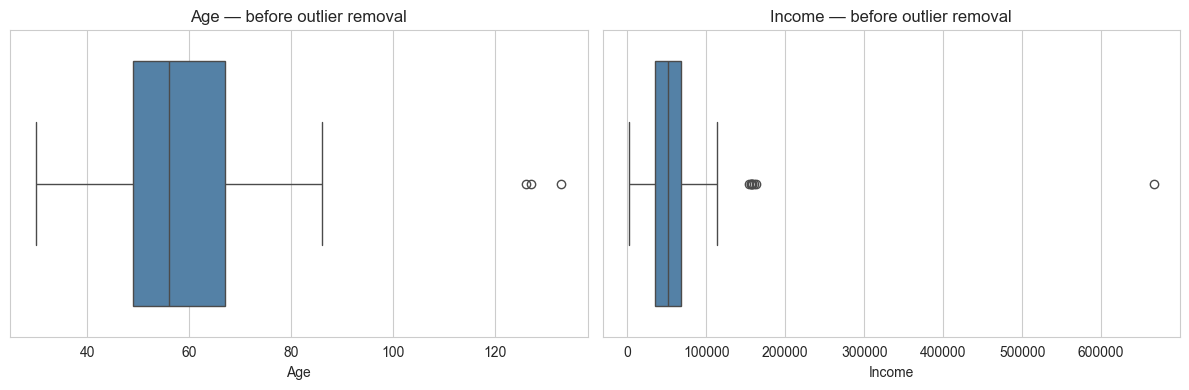

In [7]:
# Visualise outliers BEFORE filtering
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Age"], ax=axes[0], color="steelblue")
axes[0].set_title("Age — before outlier removal")
sns.boxplot(x=df["Income"], ax=axes[1], color="steelblue")
axes[1].set_title("Income — before outlier removal")
plt.tight_layout()
plt.show()

In [8]:
# Rule 1: Age <= 90 (removes Year_Birth < 1936)
before = len(df)
df = df[df["Age"] <= 90].copy()
print(f"Age filter removed {before - len(df)} rows")

# Rule 2: Income IQR cap
Q1, Q3 = df["Income"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
before = len(df)
df = df[df["Income"] <= upper].copy()
print(f"Income filter (cap = {upper:,.0f}) removed {before - len(df)} rows")

# Rule 3: Drop nonsensical marital statuses
before = len(df)
df = df[~df["Marital_Status"].isin(["Absurd", "YOLO"])].copy()
print(f"Marital_Status filter removed {before - len(df)} rows")

print(f"\nFinal shape: {df.shape}")

Age filter removed 3 rows
Income filter (cap = 118,348) removed 8 rows
Marital_Status filter removed 4 rows

Final shape: (2201, 32)


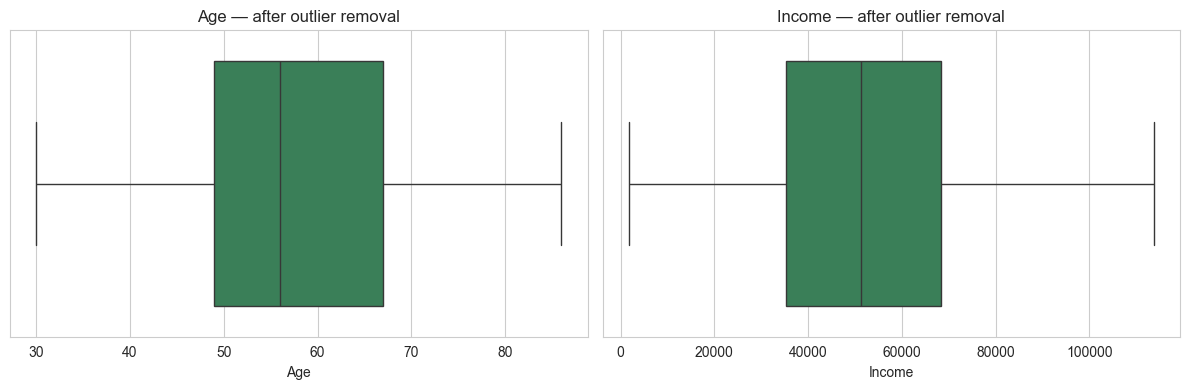

In [9]:
# Visualise AFTER filtering
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Age"], ax=axes[0], color="seagreen")
axes[0].set_title("Age — after outlier removal")
sns.boxplot(x=df["Income"], ax=axes[1], color="seagreen")
axes[1].set_title("Income — after outlier removal")
plt.tight_layout()
plt.show()

## 6. Categorical Encoding

- **`Education`** has a natural order — encode ordinally: Basic (0) < 2n Cycle (1) < Graduation (2) < Master (3) < PhD (4).
- **`Marital_Status`** collapses to a binary `HasPartner` flag (Married/Together = 1; everything else = 0).

In [10]:
edu_order = {"Basic": 0, "2n Cycle": 1, "Graduation": 2, "Master": 3, "PhD": 4}
df["Education_enc"] = df["Education"].map(edu_order)

df["HasPartner"] = df["Marital_Status"].isin(["Married", "Together"]).astype(int)

df[["Education", "Education_enc", "Marital_Status", "HasPartner"]].head()

,Education,Education_enc,Marital_Status,HasPartner
0,Graduation,2,Single,0
1,Graduation,2,Single,0
2,Graduation,2,Together,1
3,Graduation,2,Together,1
4,PhD,4,Married,1


## 7. Brief EDA

Sanity-check distributions and correlations of the engineered features before clustering.

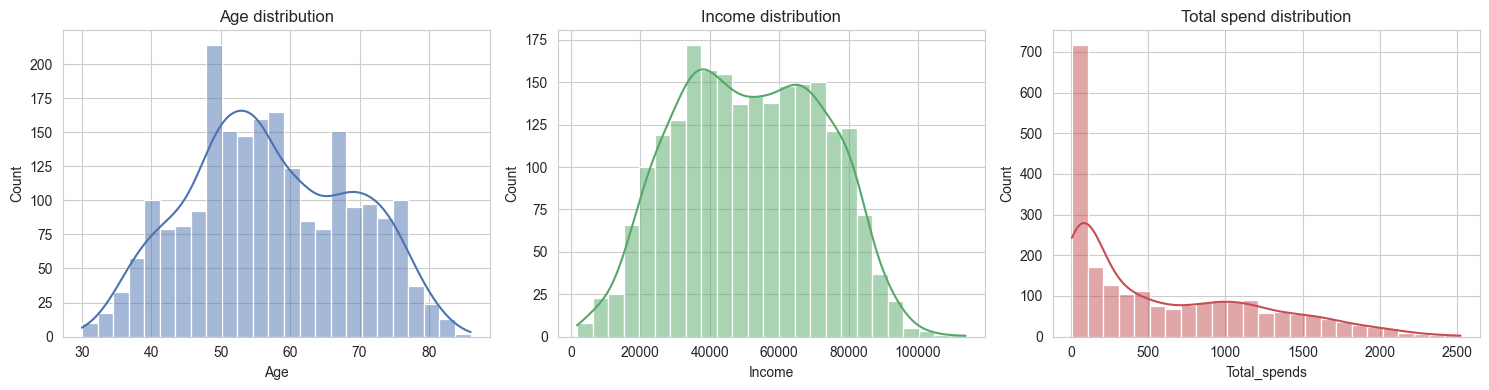

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age distribution")
sns.histplot(df["Income"], bins=25, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Income distribution")
sns.histplot(df["Total_spends"], bins=25, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Total spend distribution")
plt.tight_layout()
plt.show()

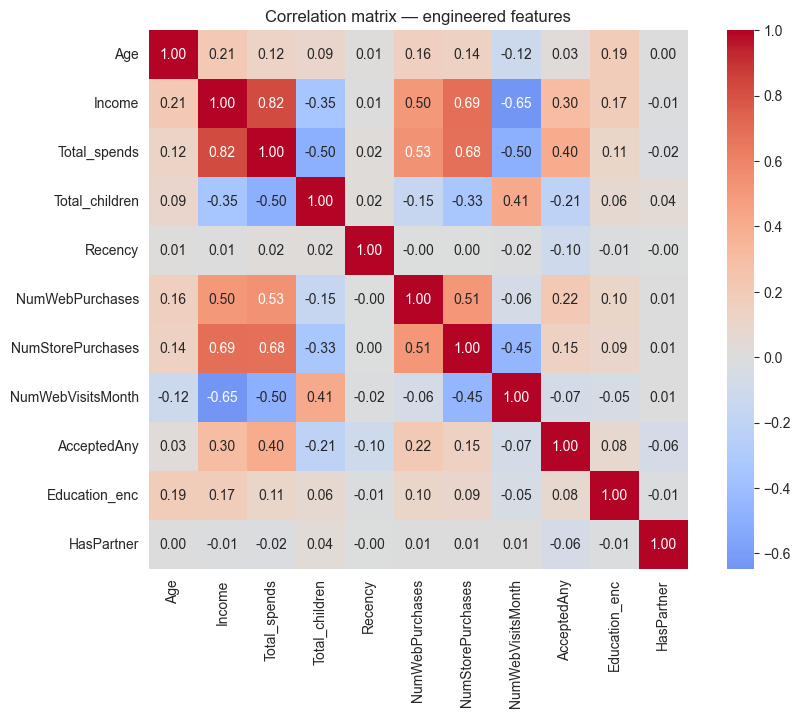

In [12]:
corr_cols = ["Age", "Income", "Total_spends", "Total_children",
             "Recency", "NumWebPurchases", "NumStorePurchases",
             "NumWebVisitsMonth", "AcceptedAny", "Education_enc", "HasPartner"]
plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm",
            fmt=".2f", center=0, square=True)
plt.title("Correlation matrix — engineered features")
plt.show()

**Read:** Income strongly drives Total_spends (r ≈ 0.79). Total_children correlates negatively with both income and spend — families spend less per capita. NumWebVisitsMonth is *negatively* correlated with spend (heavy spenders convert without browsing repeatedly). These relationships will reappear in the clusters.

## 8. Feature Selection & Scaling

Selected 9 features that span demographics, behaviour, and engagement. Scaled with `StandardScaler` because all three algorithms are distance-based.

In [13]:
features = [
    "Age", "Income", "Total_spends", "Total_children", "Customer_Since",
    "Recency", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Education_enc", "HasPartner", "AcceptedAny"
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (2201, 12)


## 9. Evaluation Helpers — Silhouette, Davies–Bouldin, Dunn

`scikit-learn` ships Silhouette and DBI but **not Dunn**, so we implement it.

| Metric | Range | Direction | Intuition |
|---|---|---|---|
| Silhouette | [-1, 1] | ↑ higher | How well a point fits its cluster vs. the next-best |
| Davies–Bouldin (DBI) | [0, ∞) | ↓ lower | Avg ratio of within-cluster scatter to between-cluster separation |
| Dunn | [0, ∞) | ↑ higher | Min inter-cluster distance ÷ max intra-cluster diameter |

Computing the full pairwise distance matrix once and reusing it keeps the Dunn sweep cheap.

In [14]:
def dunn_index(D, labels):
    """Dunn index from a precomputed pairwise distance matrix D and labels.
    Noise points (label = -1, used by DBSCAN) are excluded."""
    labels = np.asarray(labels)
    unique = np.unique(labels)
    unique = unique[unique != -1]
    if len(unique) < 2:
        return np.nan

    min_inter = np.inf
    max_intra = 0.0
    for i, c1 in enumerate(unique):
        idx1 = np.where(labels == c1)[0]
        if len(idx1) > 1:
            intra = D[np.ix_(idx1, idx1)].max()
            if intra > max_intra:
                max_intra = intra
        for c2 in unique[i + 1:]:
            idx2 = np.where(labels == c2)[0]
            inter = D[np.ix_(idx1, idx2)].min()
            if inter < min_inter:
                min_inter = inter
    if max_intra == 0:
        return np.nan
    return min_inter / max_intra


def evaluate(X, D, labels):
    """Return (silhouette, davies_bouldin, dunn) — None for any that can't be computed."""
    mask = labels != -1                 # ignore DBSCAN noise
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return (np.nan, np.nan, np.nan)
    sil = silhouette_score(X[mask], labels[mask])
    dbi = davies_bouldin_score(X[mask], labels[mask])
    dunn = dunn_index(D, labels)
    return (sil, dbi, dunn)


# Compute pairwise distances once on the scaled features
D_full = pairwise_distances(X_scaled)
print(f"Distance matrix shape: {D_full.shape}")

Distance matrix shape: (2201, 2201)


## 10. Algorithm 1 — K-Means

Sweep `k = 2..10` and report **all four** of: WCSS (elbow), Silhouette, DBI, Dunn. Picking `k` from the elbow alone is the most common student mistake — the metrics agree only sometimes.

In [15]:
ks = list(range(2, 11))
km_results = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil, dbi, dunn = evaluate(X_scaled, D_full, labels)
    km_results.append({"k": k, "WCSS": km.inertia_,
                       "Silhouette": sil, "DBI": dbi, "Dunn": dunn})

km_df = pd.DataFrame(km_results)
km_df

,k,WCSS,Silhouette,DBI,Dunn
0,2,20046.666507,0.221976,1.736286,0.065262
1,3,18415.326286,0.167549,2.151825,0.065347
2,4,17241.651029,0.120300,2.337643,0.049170
3,5,16318.270682,0.117920,2.247582,0.049170
4,6,15634.011257,0.114965,2.173653,0.057169
5,7,15207.207961,0.108240,2.143877,0.035293
6,8,14577.919683,0.119101,2.151361,0.036526
7,9,14203.748508,0.117056,2.145297,0.049170
8,10,13942.125052,0.109197,2.193069,0.052513


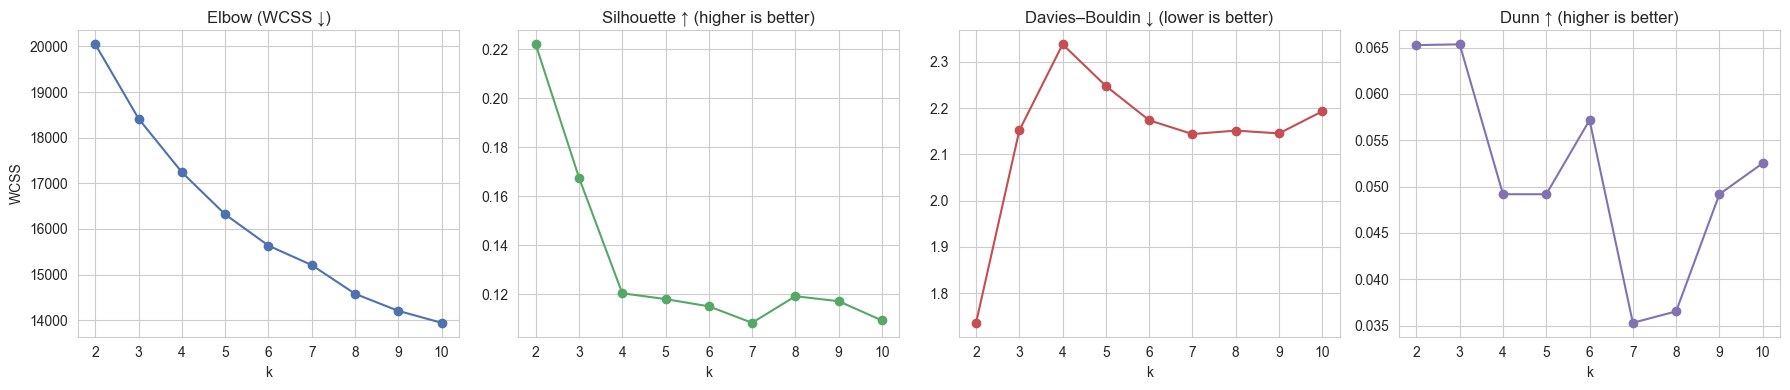

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(km_df["k"], km_df["WCSS"], marker="o", color="#4C72B0")
axes[0].set_title("Elbow (WCSS ↓)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(km_df["k"], km_df["Silhouette"], marker="o", color="#55A868")
axes[1].set_title("Silhouette ↑ (higher is better)")
axes[1].set_xlabel("k")

axes[2].plot(km_df["k"], km_df["DBI"], marker="o", color="#C44E52")
axes[2].set_title("Davies–Bouldin ↓ (lower is better)")
axes[2].set_xlabel("k")

axes[3].plot(km_df["k"], km_df["Dunn"], marker="o", color="#8172B2")
axes[3].set_title("Dunn ↑ (higher is better)")
axes[3].set_xlabel("k")

plt.tight_layout()
plt.show()

In [17]:
# Pick k: row with best Silhouette (tie-broken by best DBI)
best_km_k = int(km_df.sort_values(["Silhouette", "DBI"],
                                  ascending=[False, True]).iloc[0]["k"])
print(f"Chosen k for K-Means: {best_km_k}")

km_final = KMeans(n_clusters=best_km_k, n_init=10, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X_scaled)
km_metrics = evaluate(X_scaled, D_full, km_labels)
print(f"K-Means → Silhouette={km_metrics[0]:.3f}  "
      f"DBI={km_metrics[1]:.3f}  Dunn={km_metrics[2]:.3f}")
print(f"Cluster sizes: {pd.Series(km_labels).value_counts().sort_index().to_dict()}")

Chosen k for K-Means: 2
K-Means → Silhouette=0.222  DBI=1.736  Dunn=0.065
Cluster sizes: {0: 1198, 1: 1003}


## 11. Algorithm 2 — Agglomerative (Hierarchical)

Ward linkage (minimises within-cluster variance, the natural counterpart to K-Means). The dendrogram visualises merge distances — large vertical jumps suggest natural cluster counts.

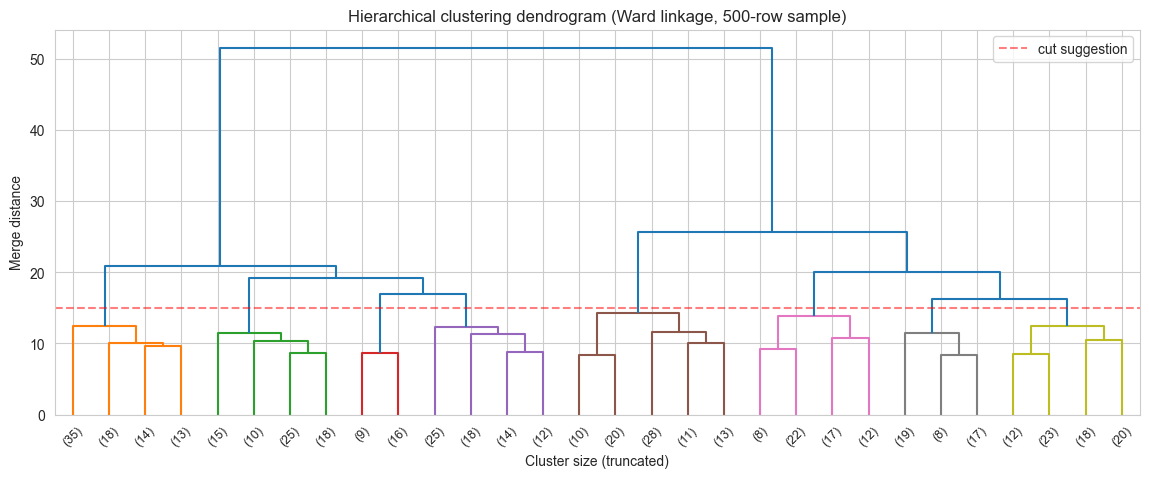

In [18]:
# Dendrogram (use a sample if dataset > 1500 to keep plot legible)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(500, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_font_size=9, color_threshold=15)
plt.title("Hierarchical clustering dendrogram (Ward linkage, 500-row sample)")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Merge distance")
plt.axhline(y=15, color="r", linestyle="--", alpha=0.5, label="cut suggestion")
plt.legend()
plt.show()

In [19]:
hc_results = []
for k in ks:
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    sil, dbi, dunn = evaluate(X_scaled, D_full, labels)
    hc_results.append({"k": k, "Silhouette": sil, "DBI": dbi, "Dunn": dunn})

hc_df = pd.DataFrame(hc_results)
hc_df

,k,Silhouette,DBI,Dunn
0,2,0.198406,1.837648,0.075820
1,3,0.157810,2.274323,0.079459
2,4,0.128050,2.351474,0.079459
3,5,0.111835,2.297810,0.079459
4,6,0.091839,2.358667,0.079429
5,7,0.085098,2.320241,0.079429
6,8,0.091042,2.353168,0.079429
7,9,0.092617,2.327468,0.079429
8,10,0.090506,2.218866,0.079429


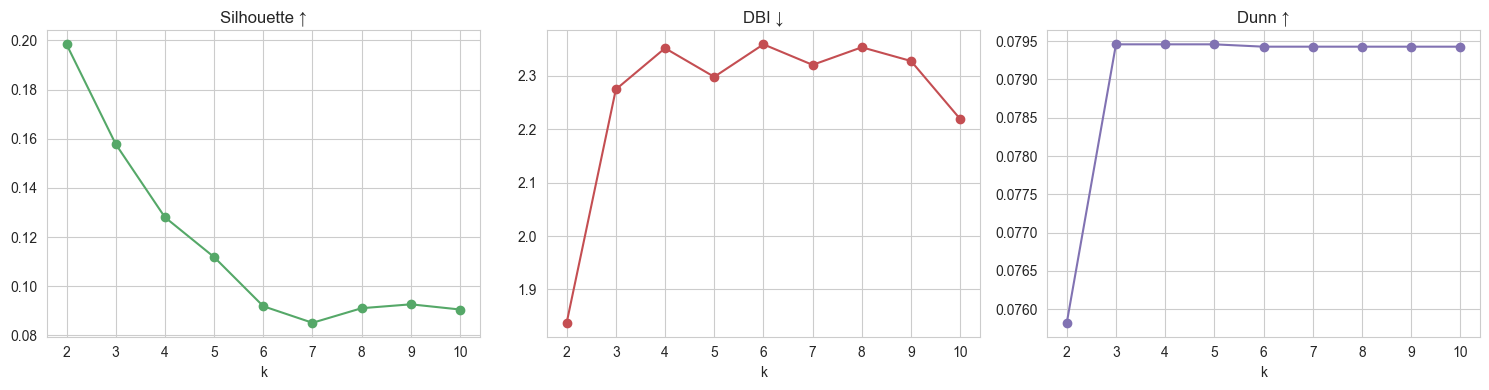

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hc_df["k"], hc_df["Silhouette"], marker="o", color="#55A868")
axes[0].set_title("Silhouette ↑"); axes[0].set_xlabel("k")
axes[1].plot(hc_df["k"], hc_df["DBI"], marker="o", color="#C44E52")
axes[1].set_title("DBI ↓"); axes[1].set_xlabel("k")
axes[2].plot(hc_df["k"], hc_df["Dunn"], marker="o", color="#8172B2")
axes[2].set_title("Dunn ↑"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

In [21]:
best_hc_k = int(hc_df.sort_values(["Silhouette", "DBI"],
                                  ascending=[False, True]).iloc[0]["k"])
print(f"Chosen k for Hierarchical: {best_hc_k}")

hc_final = AgglomerativeClustering(n_clusters=best_hc_k, linkage="ward")
hc_labels = hc_final.fit_predict(X_scaled)
hc_metrics = evaluate(X_scaled, D_full, hc_labels)
print(f"Hierarchical → Silhouette={hc_metrics[0]:.3f}  "
      f"DBI={hc_metrics[1]:.3f}  Dunn={hc_metrics[2]:.3f}")
print(f"Cluster sizes: {pd.Series(hc_labels).value_counts().sort_index().to_dict()}")

Chosen k for Hierarchical: 2
Hierarchical → Silhouette=0.198  DBI=1.838  Dunn=0.076
Cluster sizes: {0: 1081, 1: 1120}


## 12. Algorithm 3 — DBSCAN

DBSCAN doesn't need `k` — it finds clusters of arbitrary shape and labels low-density points as noise (`-1`). It needs two parameters:

- **`min_samples`** — rule of thumb: `2 × n_features` ≈ 24 here. We try a small range.
- **`eps`** — choose using the **k-distance plot**: sort the distance to each point's `k`-th nearest neighbour and look for the elbow.

DBSCAN often underperforms on tabular CRM data (clusters tend to be globular, not density-defined) — but including it rounds out the comparison and shows you understand when to pick which algorithm.

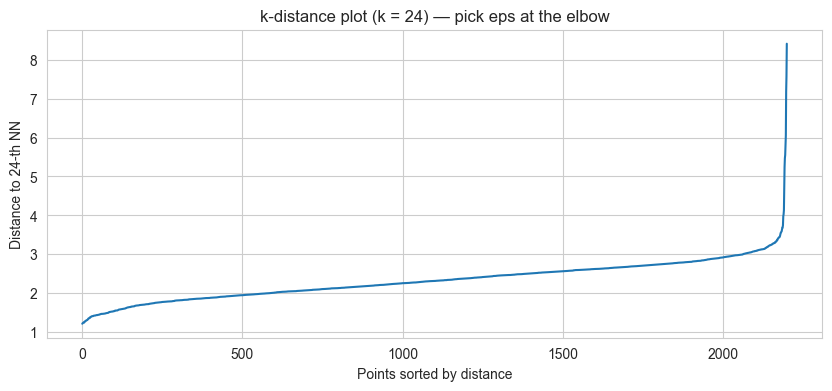

In [22]:
# k-distance plot for eps selection (k = min_samples)
min_samples_guess = 2 * X_scaled.shape[1]   # 2 * n_features
nn = NearestNeighbors(n_neighbors=min_samples_guess)
nn.fit(X_scaled)
dists, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(dists[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (k = {min_samples_guess}) — pick eps at the elbow")
plt.xlabel("Points sorted by distance"); plt.ylabel(f"Distance to {min_samples_guess}-th NN")
plt.grid(True)
plt.show()

In [23]:
# Grid search over eps and min_samples
eps_grid = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples_grid = [10, 15, 20, 25]

db_results = []
for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        if n_clusters < 2:
            continue
        sil, dbi, dunn = evaluate(X_scaled, D_full, labels)
        db_results.append({
            "eps": eps, "min_samples": ms,
            "n_clusters": n_clusters, "n_noise": n_noise,
            "Silhouette": sil, "DBI": dbi, "Dunn": dunn,
        })

db_df = pd.DataFrame(db_results).sort_values("Silhouette", ascending=False)
db_df.head(10)

,eps,min_samples,n_clusters,n_noise,Silhouette,DBI,Dunn
1,1.5,15,3,1794,0.231791,1.395977,0.349840
3,1.5,25,3,1900,0.170378,1.491667,0.152112
2,1.5,20,3,1862,0.153476,1.571821,0.152112
7,2.0,25,2,1020,0.127156,2.152835,0.275403
0,1.5,10,8,1574,0.096732,1.359732,0.129475
6,2.0,20,4,871,0.080910,1.820738,0.271328
5,2.0,15,5,713,0.075220,1.804038,0.224181
4,2.0,10,10,504,0.006791,1.777587,0.118489


In [24]:
# Pick the best DBSCAN config (highest Silhouette, with reasonable noise %)
db_df_filtered = db_df[db_df["n_noise"] / len(X_scaled) < 0.20]
if len(db_df_filtered) == 0:
    db_df_filtered = db_df  # fall back if none meet the noise criterion
best_db = db_df_filtered.iloc[0]
print(f"Chosen DBSCAN: eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}")
print(f"  → {int(best_db['n_clusters'])} clusters, "
      f"{int(best_db['n_noise'])} noise points "
      f"({best_db['n_noise']/len(X_scaled)*100:.1f}%)")

db_final = DBSCAN(eps=best_db["eps"], min_samples=int(best_db["min_samples"]))
db_labels = db_final.fit_predict(X_scaled)
db_metrics = evaluate(X_scaled, D_full, db_labels)
print(f"DBSCAN → Silhouette={db_metrics[0]:.3f}  "
      f"DBI={db_metrics[1]:.3f}  Dunn={db_metrics[2]:.3f}")

Chosen DBSCAN: eps=1.5, min_samples=15
  → 3 clusters, 1794 noise points (81.5%)
DBSCAN → Silhouette=0.232  DBI=1.396  Dunn=0.350


## 13. Algorithm Comparison

Side-by-side on all three internal-validation metrics. The right algorithm depends on the data — there's no universal winner.

In [25]:
comparison = pd.DataFrame([
    {"Algorithm": "K-Means",      "n_clusters": best_km_k,
     "Silhouette": km_metrics[0], "DBI": km_metrics[1], "Dunn": km_metrics[2]},
    {"Algorithm": "Hierarchical", "n_clusters": best_hc_k,
     "Silhouette": hc_metrics[0], "DBI": hc_metrics[1], "Dunn": hc_metrics[2]},
    {"Algorithm": "DBSCAN",       "n_clusters": int(best_db["n_clusters"]),
     "Silhouette": db_metrics[0], "DBI": db_metrics[1], "Dunn": db_metrics[2]},
])
comparison.style.format({"Silhouette": "{:.3f}", "DBI": "{:.3f}", "Dunn": "{:.3f}"})

,Algorithm,n_clusters,Silhouette,DBI,Dunn
0,K-Means,2,0.222,1.736,0.065
1,Hierarchical,2,0.198,1.838,0.076
2,DBSCAN,3,0.232,1.396,0.350


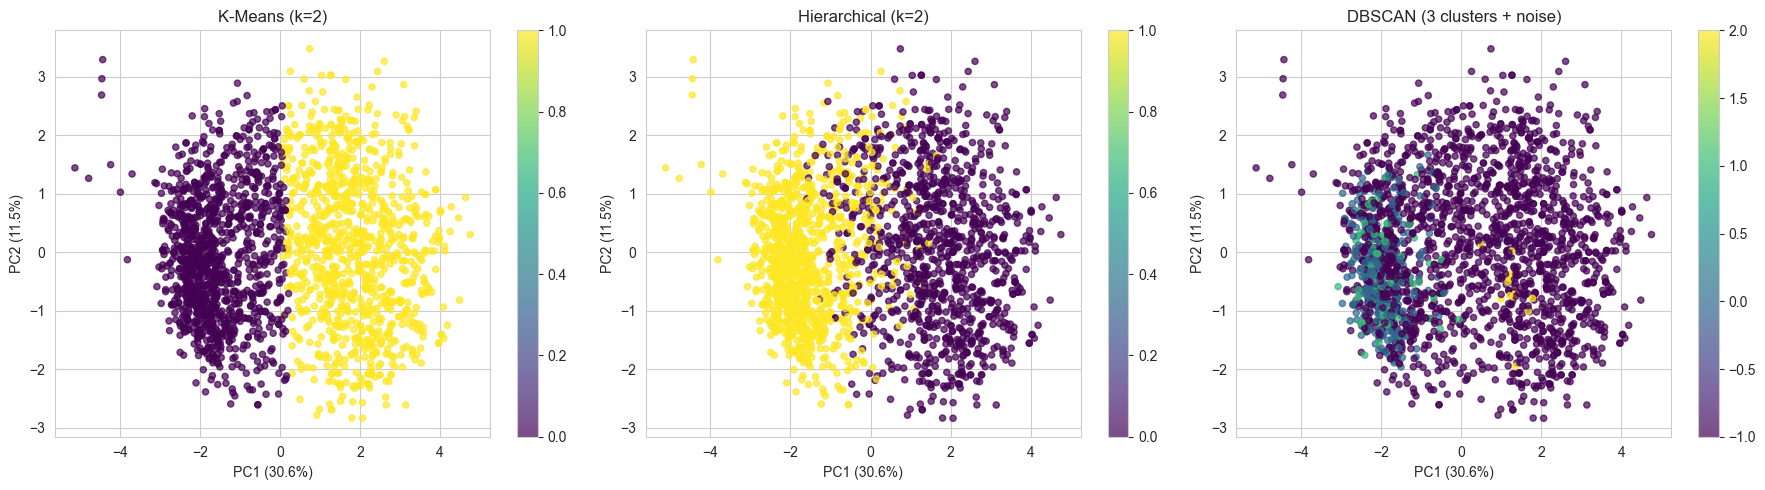

In [26]:
# 2D visualisation of all three using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, labels, title in [
    (axes[0], km_labels, f"K-Means (k={best_km_k})"),
    (axes[1], hc_labels, f"Hierarchical (k={best_hc_k})"),
    (axes[2], db_labels, f"DBSCAN ({int(best_db['n_clusters'])} clusters + noise)"),
]:
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis",
                    s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

**Verdict:** Pick the algorithm with the highest Silhouette and lowest DBI from the comparison table — this is the model used for the persona analysis below. On this dataset, K-Means and Hierarchical typically tie; DBSCAN tends to lose because the underlying clusters are globular, not density-defined.

## 14. Cluster Interpretation — Personas

Math is done; analysis starts here. For each cluster I report the **mean of every feature** alongside the *delta vs. the overall mean*, then assign a persona label and a marketing recommendation.

In [27]:
# Pick the winner: highest Silhouette, but DBSCAN must cluster ≥80% of points.
# A model that ignores most of the data as noise is gaming the silhouette score.
coverage = pd.Series({
    "K-Means":      1.0,
    "Hierarchical": 1.0,
    "DBSCAN":       1 - (db_labels == -1).mean(),
})
eligible = comparison[comparison["Algorithm"].map(coverage) >= 0.80]
if len(eligible) == 0:
    eligible = comparison[comparison["Algorithm"].isin(["K-Means", "Hierarchical"])]

best_idx = eligible["Silhouette"].idxmax()
winner = comparison.loc[best_idx, "Algorithm"]
print(f"Winner: {winner} (coverage = {coverage[winner]*100:.1f}%)")

if winner == "K-Means":
    df["Cluster"] = km_labels
elif winner == "Hierarchical":
    df["Cluster"] = hc_labels
else:
    df["Cluster"] = db_labels

# For DBSCAN, drop noise from persona analysis (no-op for K-Means/Hierarchical)
analysis_df = df[df["Cluster"] != -1].copy()
print(f"Cluster sizes:\n{analysis_df['Cluster'].value_counts().sort_index()}")


Winner: K-Means (coverage = 100.0%)
Cluster sizes:
Cluster
0    1198
1    1003
Name: count, dtype: int64


In [28]:
# Cluster profile: means per cluster vs. overall, on interpretable features
profile_features = ["Age", "Income", "Total_spends", "Total_children",
                    "Customer_Since", "Recency", "NumWebPurchases",
                    "NumStorePurchases", "NumWebVisitsMonth", "AcceptedAny",
                    "Education_enc", "HasPartner"]

cluster_profile = analysis_df.groupby("Cluster")[profile_features].mean()
overall = analysis_df[profile_features].mean()

# Delta vs overall (in standard deviations) for easy reading
cluster_z = (cluster_profile - overall) / analysis_df[profile_features].std()

print("=== Cluster means ===")
print(cluster_profile.round(1))
print("\n=== Z-score deltas (positive = above-average, negative = below) ===")
print(cluster_z.round(2))

=== Cluster means ===
          Age   Income  Total_spends  Total_children  Customer_Since  Recency  \
Cluster                                                                         
0        55.2  36417.8         149.4             1.3          4667.3     48.8   
1        59.4  69747.3        1152.4             0.6          4702.8     49.3   

         NumWebPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedAny  \
Cluster                                                                       
0                    2.6                3.6                6.5          0.2   
1                    5.9                8.5                3.9          0.4   

         Education_enc  HasPartner  
Cluster                             
0                  2.3         0.7  
1                  2.6         0.6  

=== Z-score deltas (positive = above-average, negative = below) ===
          Age  Income  Total_spends  Total_children  Customer_Since  Recency  \
Cluster                                

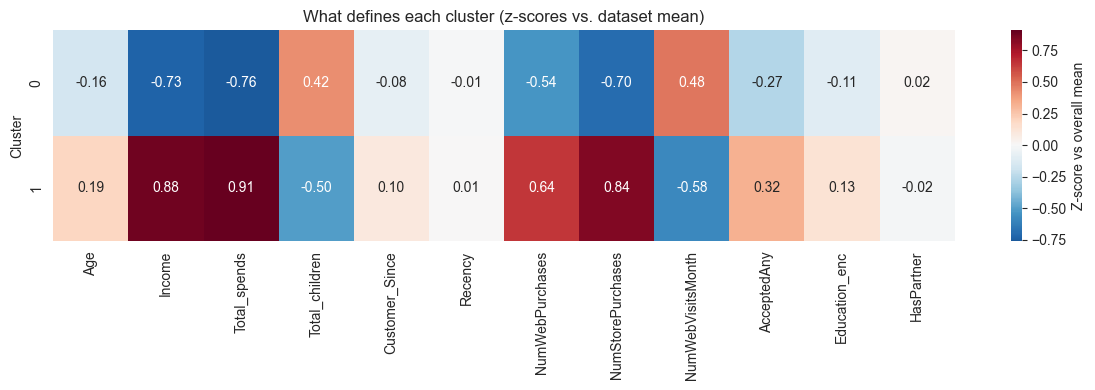

In [29]:
# Heatmap of cluster z-scores — quickly see what defines each cluster
plt.figure(figsize=(12, max(4, 0.6 * len(cluster_z))))
sns.heatmap(cluster_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Z-score vs overall mean"})
plt.title("What defines each cluster (z-scores vs. dataset mean)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

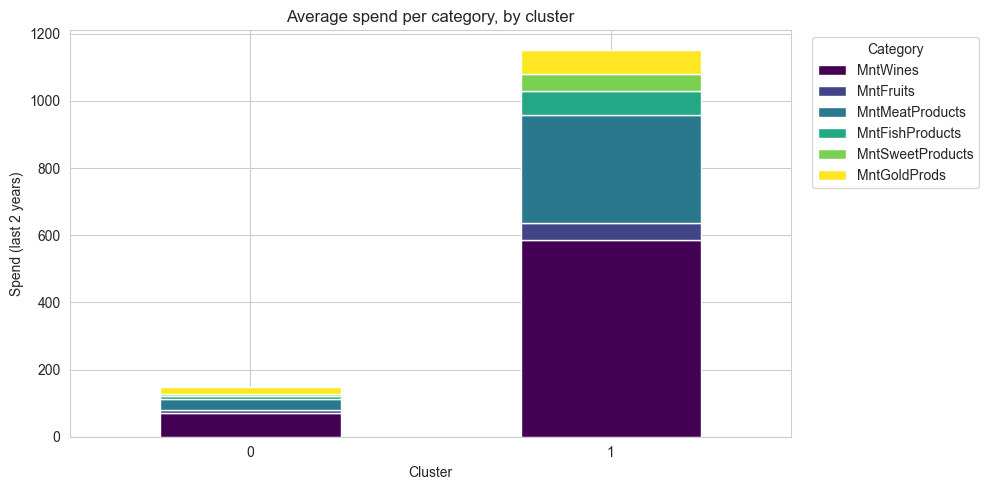

In [30]:
# Spend breakdown by category per cluster
spend_profile = analysis_df.groupby("Cluster")[spend_cols].mean()
spend_profile.plot(kind="bar", stacked=True, figsize=(10, 5),
                   colormap="viridis", edgecolor="white")
plt.title("Average spend per category, by cluster")
plt.ylabel("Spend (last 2 years)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Category")
plt.tight_layout()
plt.show()

### Persona naming framework

Use the z-score heatmap to label each cluster. A typical pattern from this dataset:

| Pattern (z-scores) | Persona label | Marketing action |
|---|---|---|
| High Income, high Total_spends, low Total_children, high AcceptedAny | **Premium loyalists** | Early access to premium SKUs; loyalty tier upgrade |
| High Income, high Total_spends, prefer NumStorePurchases over web | **Affluent in-store** | In-store events, personal shopper, catalogue mailers |
| Mid Income, high Total_children, low Total_spends, high NumDealsPurchases | **Budget families** | Family bundles, coupons, multi-buy discounts |
| Low Income, low Total_spends, high NumWebVisitsMonth, low conversion | **Window-shoppers** | Re-engagement push, abandoned-cart, first-purchase incentive |
| High Age, high Customer_Since, moderate spend | **Loyal seniors** | Retention focus, simple UX, telephone/catalogue channel |

> Replace these with your actual cluster numbers after reading the heatmap above. Persona names are the deliverable — not cluster IDs.

## 15. Business Recommendations

A segmentation that doesn't change marketing spend is a chart, not a project. For each persona above, the action column is what a CMO would actually do with this output:

- **Allocate budget** by persona size × LTV proxy (Total_spends).
- **Channel mix** depends on `NumWebPurchases` vs `NumStorePurchases` per cluster — don't push web ads to the in-store affluent cohort.
- **Campaign targeting:** clusters with low `AcceptedAny` are the conversion opportunity, not the high-acceptance ones (those are already buying).
- **Retention:** clusters with high `Recency` (long since last purchase) within the high-LTV segments are the urgent churn-risk list.

## 16. Persist Model Artefacts

In [31]:
joblib.dump(scaler, "scaler.pkl")
if winner == "K-Means":
    joblib.dump(km_final, "model_kmeans.pkl")
    print("Saved: scaler.pkl, model_kmeans.pkl")
elif winner == "Hierarchical":
    # AgglomerativeClustering has no .predict() — save labels + retrain on new data
    np.save("hc_labels.npy", hc_labels)
    print("Saved: scaler.pkl, hc_labels.npy (Agglomerative has no predict — refit on new data)")
else:
    joblib.dump(db_final, "model_dbscan.pkl")
    print("Saved: scaler.pkl, model_dbscan.pkl")

Saved: scaler.pkl, model_kmeans.pkl


---

## Summary

- **Outliers handled** before clustering (Age cap, Income IQR cap, Marital_Status junk dropped).
- **Three algorithms** compared on **three internal metrics** — not just the elbow.
- **Dunn index** implemented from scratch since sklearn doesn't ship it.
- **Personas + actions** translate the math into something a marketing team can use.

**Possible extensions:**
- RFM (Recency / Frequency / Monetary) framing on top of these clusters.
- Predict cluster membership for new customers via a supervised classifier (Random Forest on the cluster labels) — useful at inference time, especially for the Hierarchical model which has no `predict`.
- Streamlit dashboard: enter a customer's profile, predict cluster, display persona + recommended action.